In [83]:
#Importing the Dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.cm as cm
import plotly.graph_objects as go
import plotly.io as pio
import warnings
from plotly.subplots import make_subplots
pio.renderers.default = "notebook_connected"
warnings.filterwarnings("ignore")


In [84]:
# Display options
pd.set_option("display.max_columns", 999)
pd.set_option("display.max_rows", 999)


In [85]:
#Read the file into memory
df = pd.read_csv(r"./data/BMW_sales_data.csv")

#Display the first 5 rows
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [86]:
#Deep instrospection
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 19.8 MB


In [87]:
##Memory the columns occupy in MBs.
color_size = df.memory_usage(deep=True) / 1e6
print("Column size (MB):")
print(color_size.apply(lambda x: f"{x:.2f}"))

##Memory the entire DataFrame occupies in MB.
memory_in_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory used: {memory_in_mb:.2f} MB")

Column size (MB):
Index                   0.00
Model                   3.03
Year                    0.40
Region                  3.29
Color                   3.07
Fuel_Type               3.17
Transmission            3.22
Engine_Size_L           0.40
Mileage_KM              0.40
Price_USD               0.40
Sales_Volume            0.40
Sales_Classification    3.02
dtype: object
Memory used: 20.81 MB


In [88]:
#Inspect a random subset of rows
df.sample(7, random_state=42)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
33553,5 Series,2024,Middle East,Grey,Diesel,Manual,4.1,119506,58342,4092,Low
9427,X1,2023,Africa,Black,Petrol,Manual,3.7,153279,82399,4207,Low
199,3 Series,2023,Asia,Grey,Diesel,Manual,2.4,58991,84635,3507,Low
12447,i8,2020,Africa,White,Hybrid,Automatic,2.3,74925,71520,2745,Low
39489,X1,2016,Asia,Red,Hybrid,Automatic,3.1,188803,48269,1337,Low
42724,M3,2017,Africa,Black,Diesel,Manual,2.8,119970,101589,1480,Low
10822,7 Series,2019,Europe,Black,Hybrid,Automatic,4.9,184135,60516,1319,Low


In [89]:
#Count of columns that belong to each datatype
df.dtypes.value_counts()

object     6
int64      4
float64    1
Name: count, dtype: int64

In [90]:
#Check for duplicates
df.duplicated().any()

np.False_

In [91]:
#Check if null entries exists at all
df.isna().values.any()

np.False_

In [92]:
#Numeric Columns Summary Statistics
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [93]:
#Categorical Columns Summary Statistics
df.describe(include="O")

,Model,Region,Color,Fuel_Type,Transmission,Sales_Classification
count,50000,50000,50000,50000,50000,50000
unique,11,6,6,4,2,2
top,7 Series,Asia,Red,Hybrid,Manual,Low
freq,4666,8454,8463,12716,25154,34754


In [94]:
#Select categorical columns
cat_cols = df.select_dtypes(include="object")

#Loop through each categorical column and print the unique values
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())
    print("---" * 20)


Column: Model
['5 Series' 'i8' 'X3' '7 Series' 'M5' '3 Series' 'X1' 'M3' 'X5' 'i3' 'X6']
------------------------------------------------------------

Column: Region
['Asia' 'North America' 'Middle East' 'South America' 'Europe' 'Africa']
------------------------------------------------------------

Column: Color
['Red' 'Blue' 'Black' 'Silver' 'White' 'Grey']
------------------------------------------------------------

Column: Fuel_Type
['Petrol' 'Hybrid' 'Diesel' 'Electric']
------------------------------------------------------------

Column: Transmission
['Manual' 'Automatic']
------------------------------------------------------------

Column: Sales_Classification
['High' 'Low']
------------------------------------------------------------


In [95]:
#Correlation Matrix
df.corr(numeric_only=True).style.background_gradient(cmap="coolwarm")


,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
Year,1.000000,-0.001944,0.008741,0.003547,0.001671
Engine_Size_L,-0.001944,1.000000,-0.004906,0.000146,-0.003942
Mileage_KM,0.008741,-0.004906,1.000000,-0.004238,0.001434
Price_USD,0.003547,0.000146,-0.004238,1.000000,0.000080
Sales_Volume,0.001671,-0.003942,0.001434,0.000080,1.000000


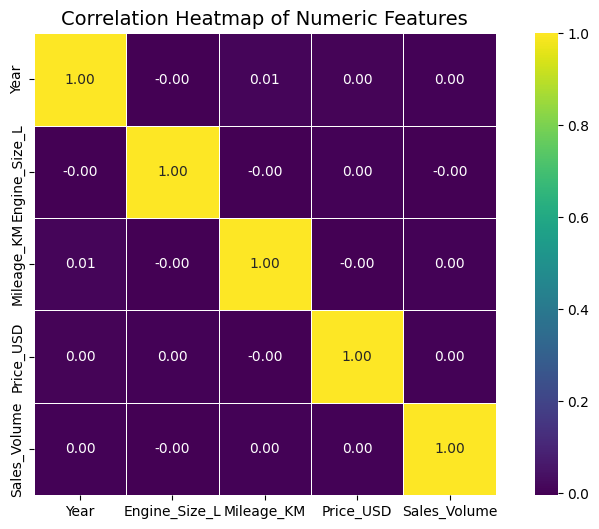

In [96]:
##Correlation Heatmap
#Compute correlation
corr = df.corr(numeric_only=True)

#Set up the figure size
plt.figure(figsize=(10, 6))

#Create the heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    square=True
)
#Title
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()

Correlation Interpretation.

Every other cell is very close to 0.00, which means:

The numeric features in the dataset are statistically independent meaning there is no linear relationship with each other.

NB: Try another different correlation metrics

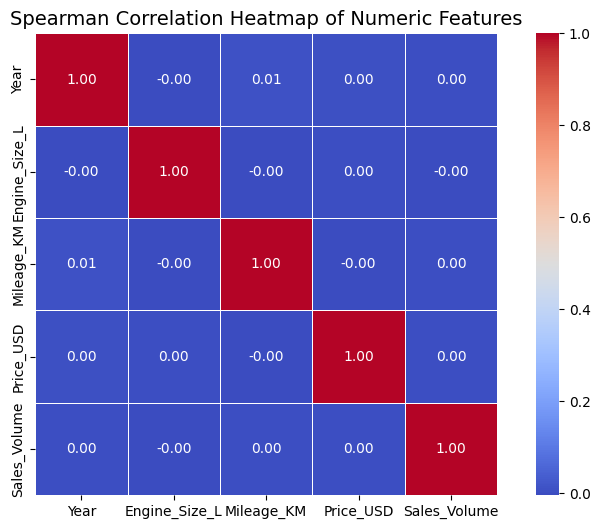

In [97]:
##Spearman correlation for monotonic but non-linear relationships
spear_corr = df.corr(method='spearman', numeric_only=True)

#Set up the figure
plt.figure(figsize=(10, 6))

#Create the heatmap
sns.heatmap(
    spear_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

#Title
plt.title("Spearman Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()


Spearman Correlation Heatmap Interpretation: 

Most off-diagonal values are still around 0.00 or -0.00

This means that no strong monotonic (increasing or decreasing) relationships exist between your numeric features.

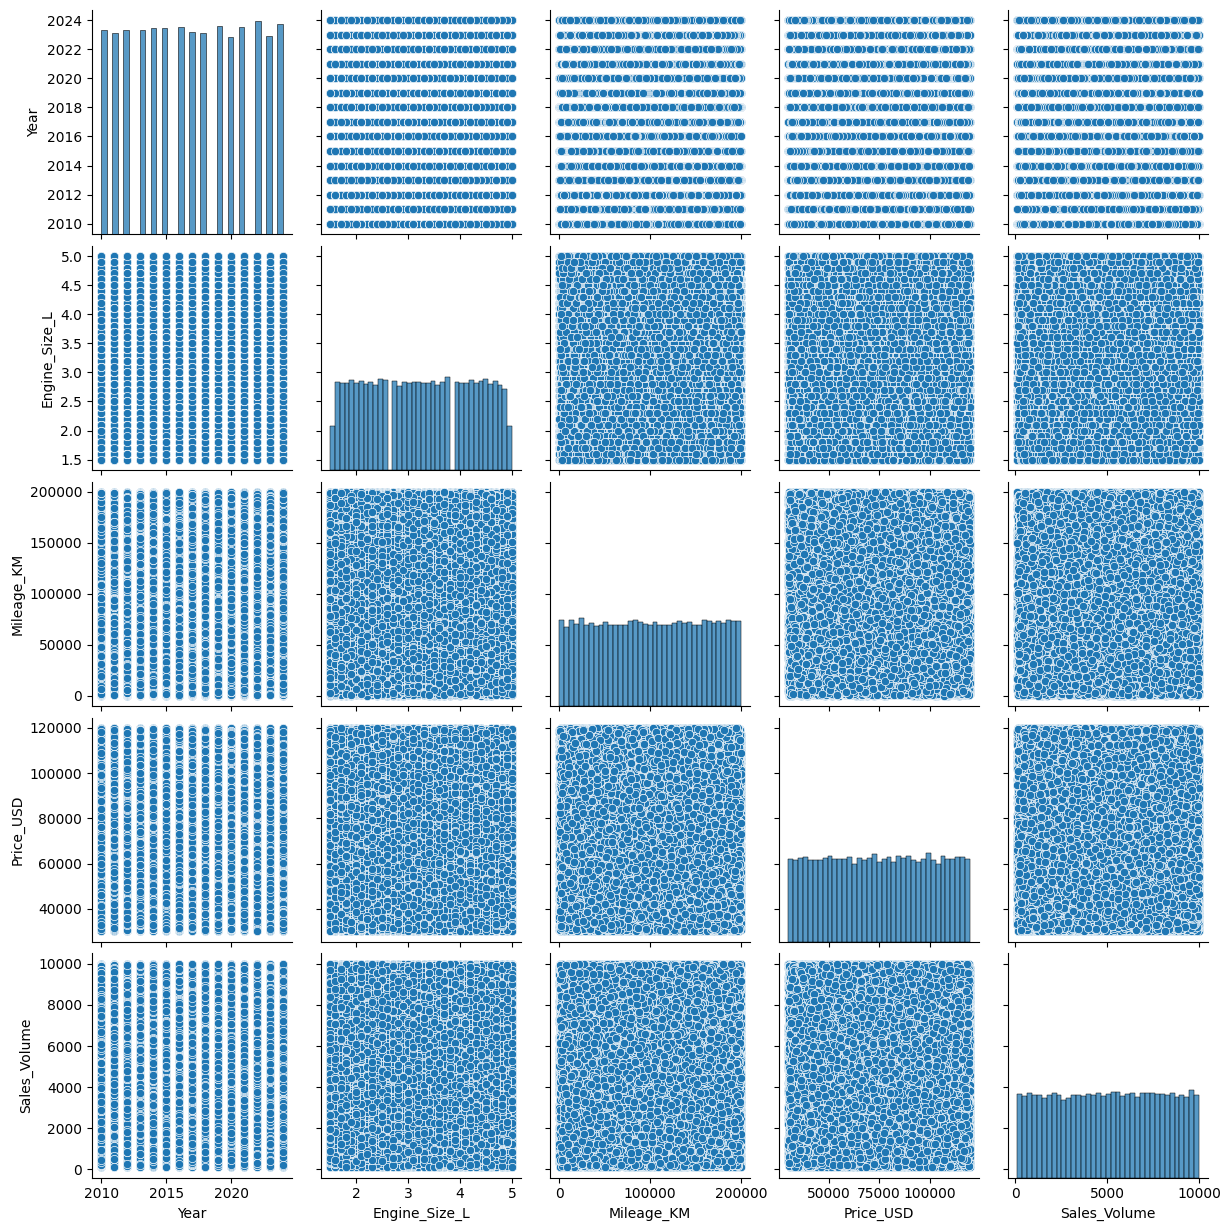

In [98]:
#Pairwise scatter plot
sns.pairplot(df)

Pairplots Interpretation:

1. Vertical & horizontal striping

Each feature forms discrete vertical/horizontal bands rather than clouds of points suggesting the features have a limited number of unique values.

2. No visible trends or slopes

None of the scatter plots show upward or downward patterns. This confirms what the Pearson and Spearman heatmaps already suggested that there is no strong linear or monotonic relationships among numeric variables.

3. Uniform horizontal spreads

Distributions look fairly even, without visible clusters. This suggests the dataset might be synthetic or preprocessed in a way that removes natural variation.

In [99]:
#Check unique counts per numeric column
df.select_dtypes(include=["int", "float"]).nunique()

Year                15
Engine_Size_L       36
Mileage_KM       44347
Price_USD        38246
Sales_Volume      9845
dtype: int64

In [100]:
#Check the unique per numeric column
numeric_cols = df.select_dtypes(include=["int", "float"]).columns
for col in numeric_cols:
    print(f"\ncolumn: {col}")
    print(f"Unique items ({df[col].nunique()}):")
    print(f"{df[col].unique()}")
    print("---" * 25)


column: Year
Unique items (15):
[2016 2013 2022 2024 2020 2017 2014 2019 2012 2015 2011 2021 2023 2010
 2018]
---------------------------------------------------------------------------

column: Engine_Size_L
Unique items (36):
[3.5 1.6 4.5 1.7 2.1 1.9 1.8 3.  2.4 3.8 2.3 2.6 3.1 3.7 4.8 3.3 3.2 2.2
 4.1 2.  4.7 4.3 4.  3.6 4.9 3.4 2.8 3.9 1.5 4.2 2.5 2.7 4.6 5.  4.4 2.9]
---------------------------------------------------------------------------

column: Mileage_KM
Unique items (44347):
[151748 121671  10991 ... 147396   3379 171003]
---------------------------------------------------------------------------

column: Price_USD
Unique items (38246):
[ 98740  79219 113265 ...  73173  48714  77492]
---------------------------------------------------------------------------

column: Sales_Volume
Unique items (9845):
[8300 3428 6994 ... 8743 4398 4341]
---------------------------------------------------------------------------


In [101]:
#Check for Skewness.
skew_values = df[numeric_cols].skew()
print(skew_values)

Year            -0.001496
Engine_Size_L   -0.001285
Mileage_KM      -0.006677
Price_USD       -0.000034
Sales_Volume    -0.012126
dtype: float64


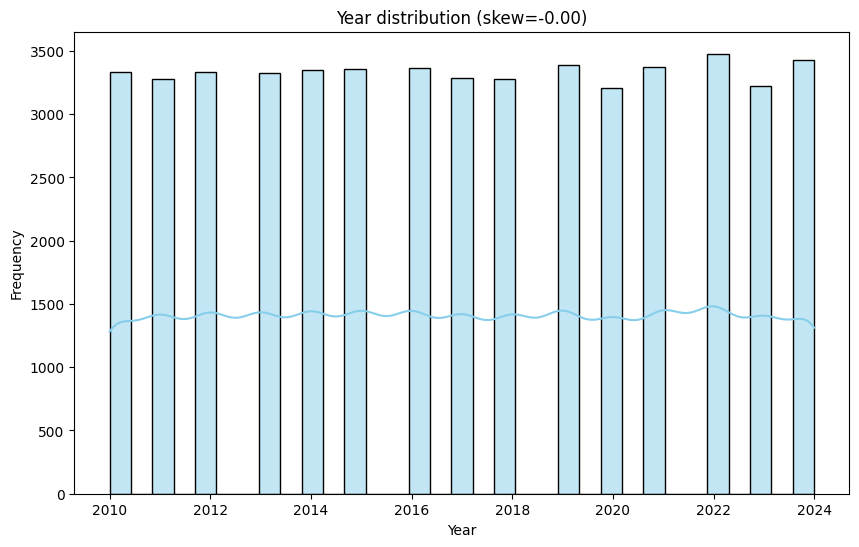

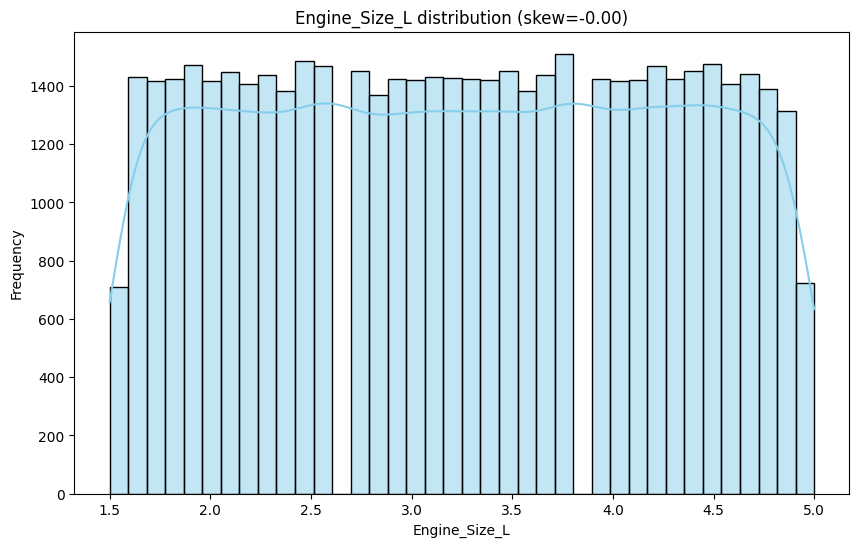

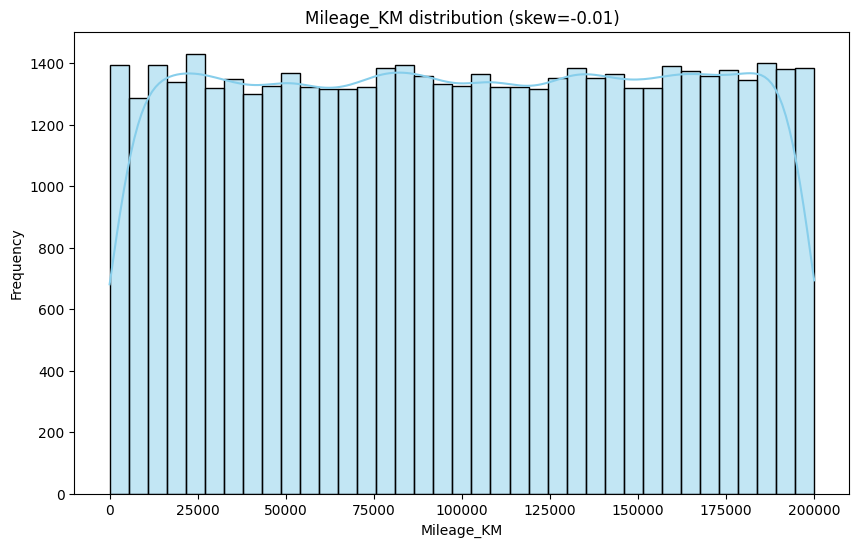

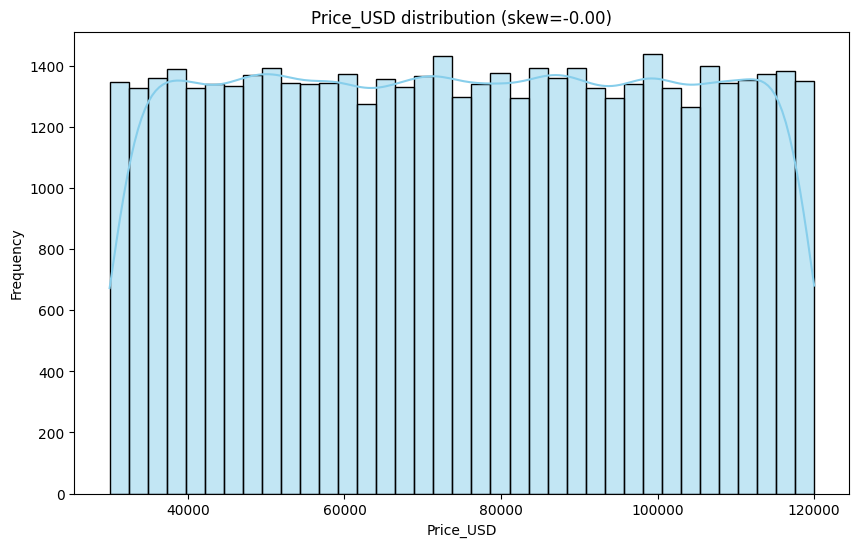

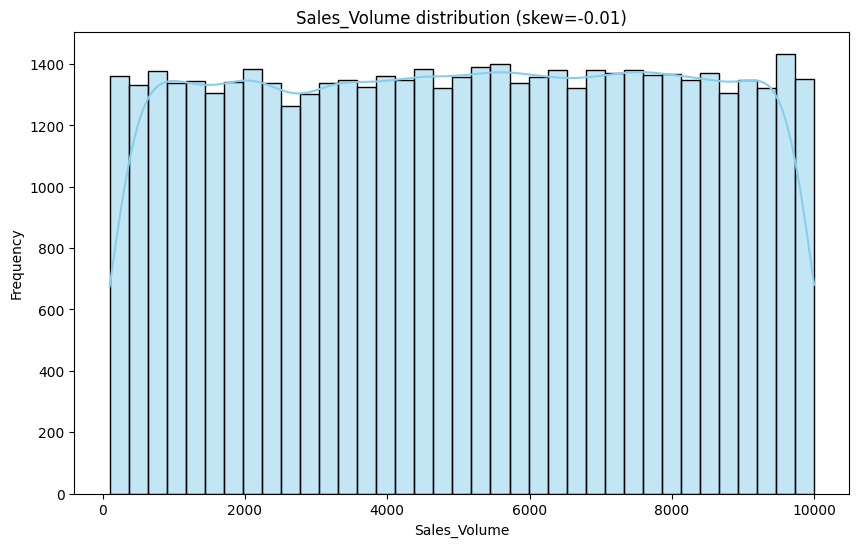

In [102]:
#Visualize Skewness for clarity
for col in numeric_cols:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True, bins="auto", color='skyblue')
    plt.title(f'{col} distribution (skew={df[col].skew():.2f})')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

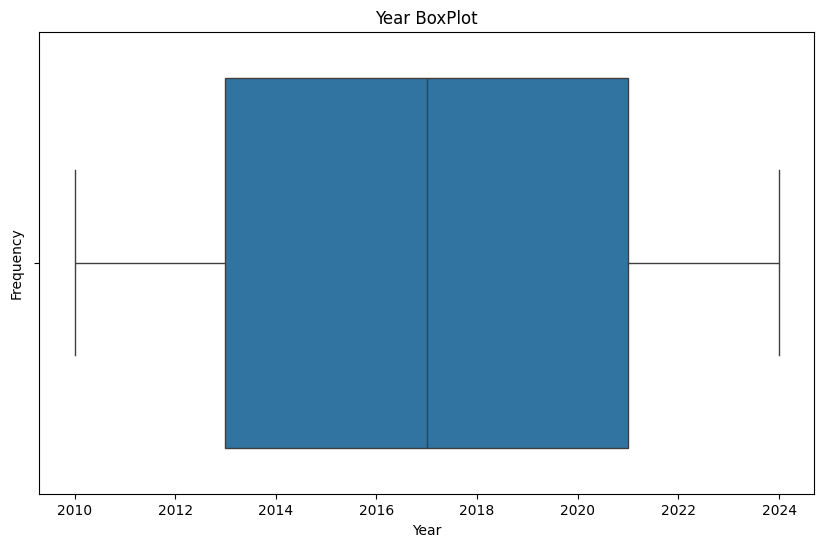

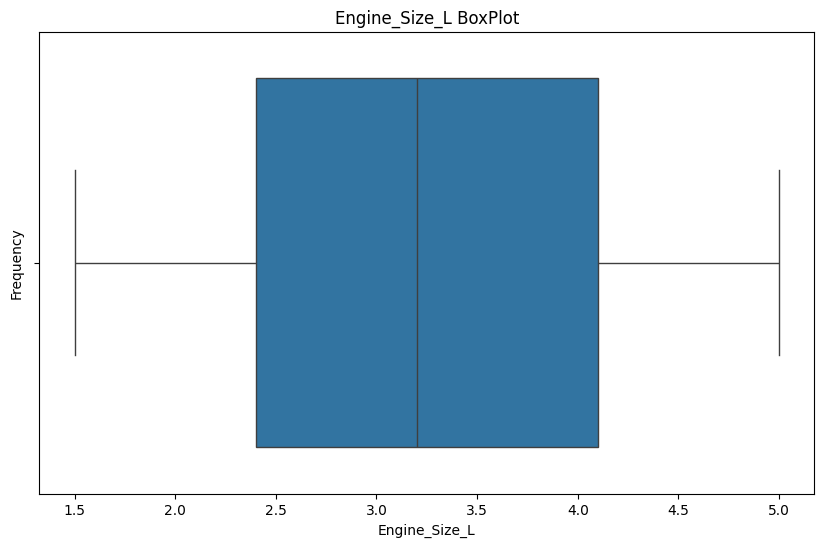

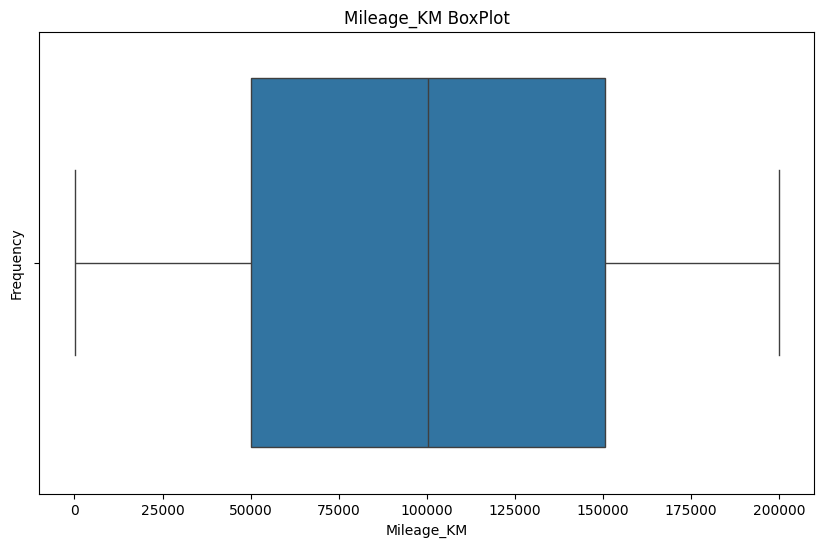

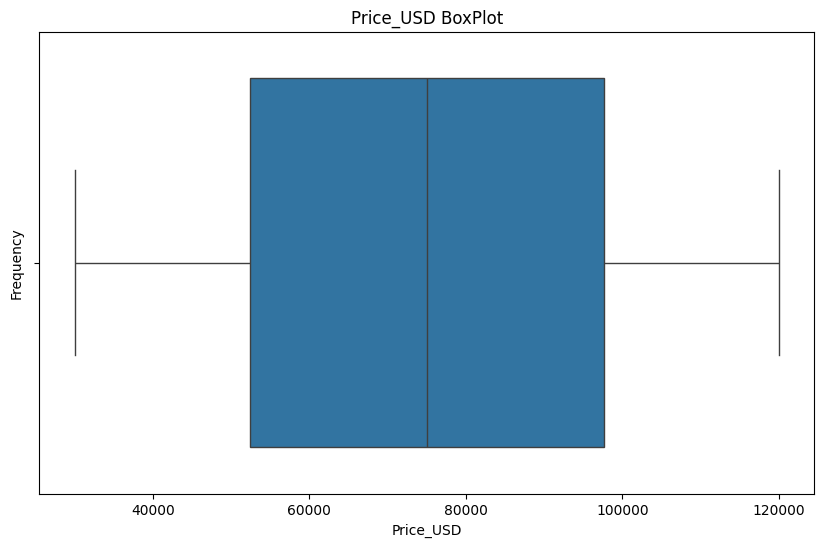

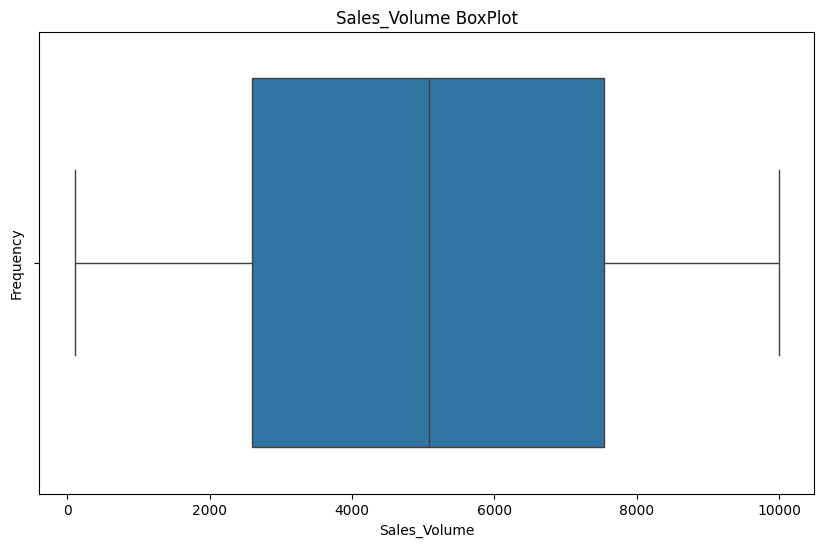

In [103]:
#BoxPlot to check for ouliers
for col in numeric_cols:
    plt.figure(figsize=(10,6))
    sns.boxplot(df[col], orient="h")
    plt.title(f'{col} BoxPlot')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

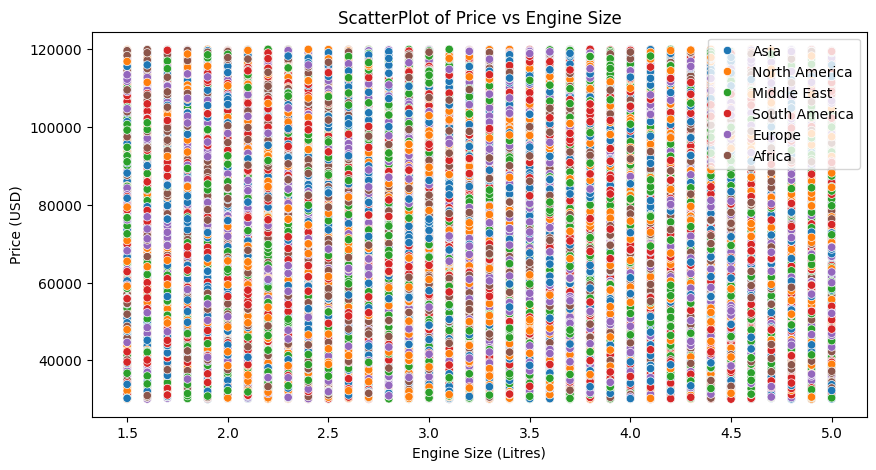

In [104]:
#MultiVariate Analysis
#ScatterOlot of Price vs Engine Size
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Engine_Size_L', y='Price_USD', hue='Region', data=df)
plt.legend(loc="best")
plt.title("ScatterPlot of Price vs Engine Size")
plt.ylabel("Price (USD)")
plt.xlabel("Engine Size (Litres)");

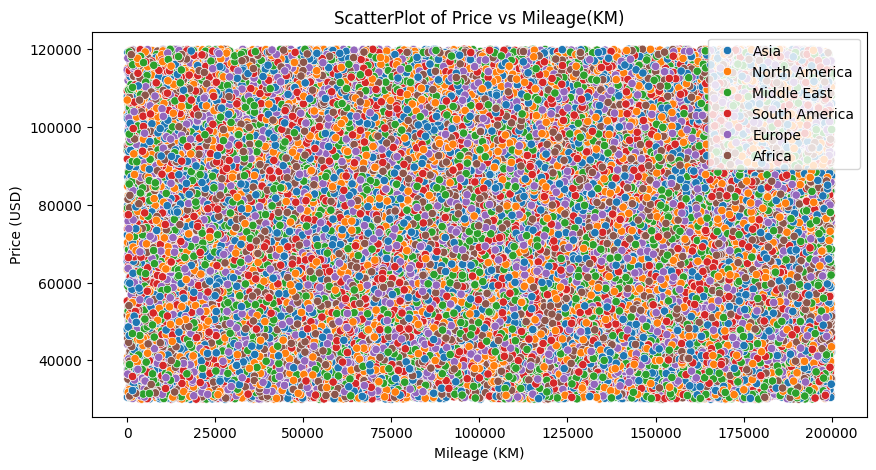

In [105]:
#ScatterPlot of Price vs Mileage
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Mileage_KM', y='Price_USD', hue='Region', data=df)
plt.legend(loc="upper right")
plt.title("ScatterPlot of Price vs Mileage(KM)")
plt.ylabel("Price (USD)")
plt.xlabel("Mileage (KM)");

In [106]:
# Yearly Sales Analysis
yearly_sales = df.groupby("Year")["Price_USD"].sum().reset_index()
yearly_sales.columns = ["Year", "Total_Sales_USD"]
yearly_sales = yearly_sales.sort_values("Total_Sales_USD")
yearly_sales.head()


,Year,Total_Sales_USD
10,2020,240559823
13,2023,242049501
1,2011,246811360
7,2017,247319655
8,2018,247343066


In [107]:
# Yearly Sales Horizontal BarChart
# Improved Yearly Sales Horizontal BarChart
fig = px.bar(
    yearly_sales,
    y="Year",
    x="Total_Sales_USD",
    orientation="h",
    text_auto='.2s',  # Automatically formats numbers (e.g., 1.2M instead of 1200000)
    title="BMW Annual Sales (USD)",
    color="Total_Sales_USD",
    color_continuous_scale="Purples"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Total Sales (USD)",
    yaxis_title="Year",
    # Dynamic height based on number of years
    height=100 + (50 * yearly_sales["Year"].nunique()), 
    template="plotly_white"
)

fig.show()




In [108]:
#Yearly Region Sales
yearly_region_sales = (
    df.groupby(["Year", "Region"])["Price_USD"]
    .sum()
    .reset_index()
    .sort_values("Year")
    .rename(columns={"Price_USD": "Total_Sales_USD"})
)
#Plot Sales Evolution Reginally
fig = px.bar(
    yearly_region_sales,
    x="Total_Sales_USD",
    y="Region",
    color="Region",
    animation_frame="Year",
    orientation="h",
    text="Total_Sales_USD",
    title="BMW Sales Evolution by Region (USD)",
    color_continuous_scale="Purples"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Total_Sales_USD",
    yaxis_title="Region",
    height=600
)
fig.show()

In [109]:
#Region-wise Yearly Sales
#Compute yearly regional sales
region_yearly_sales = (
    df.groupby(["Region", "Year"])["Price_USD"]
    .sum()
    .reset_index()
    .sort_values(["Region", "Year"])
    .rename(columns={"Price_USD": "Total_Sales_USD"})
)

#Sunburst Chart
fig = px.sunburst(
    region_yearly_sales,
    path=["Year", "Region"],
    values="Total_Sales_USD",
    color="Region",
    title="Regional Annual Sales Distribution",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    title_x=0.5,
    title_font=dict(size=20),
)
fig.show()

In [110]:
#Compute Yearly growth rate per region
region_yearly_sales["Yearly_Growth_Rate"] = (
    region_yearly_sales.groupby("Region")["Total_Sales_USD"]
    .pct_change() * 100
).round(2)
region_yearly_sales.dropna(inplace=True)

#Create a Summary Table
summary = (
    region_yearly_sales.groupby("Region")
    .agg(
        Avg_Growth_Rate=("Yearly_Growth_Rate", "mean"),
        Positive_Growth_Years=("Yearly_Growth_Rate", lambda x: (x > 0).sum())
    )
    .round(2)
    .reset_index()
)

#Identify top region per year
top_growth = region_yearly_sales.loc[
    region_yearly_sales.groupby("Year")["Yearly_Growth_Rate"].idxmax()
]

#Build combined dashboard layout
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.7, 0.3],
    subplot_titles=("Regional Year-over-Year Sales Growth (%)", "Summary Statistics"),
    specs=[[{"type": "xy"}, {"type": "table"}]]
)

#Add line chart in first column
for region in region_yearly_sales["Region"].unique():
    region_data = region_yearly_sales[region_yearly_sales["Region"] == region]
    fig.add_trace(
        go.Scatter(
            x=region_data["Year"],
            y=region_data["Yearly_Growth_Rate"],
            mode="lines+markers",
            name=region
        ),
        row=1, col=1
    )

# Add table in second column
fig.add_trace(
    go.Table(
        header=dict(
            values=["Region", "Avg Growth (%)", "Positive Years"],
            fill_color="purple",
            font=dict(color="white", size=12),
            align="left"
        ),
        cells=dict(
            values=[
                summary["Region"],
                summary["Avg_Growth_Rate"],
                summary["Positive_Growth_Years"]
            ],
            fill_color="lavender",
            align="left"
        )
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="BMW Regional Sales Growth Dashboard",
    title_x=0.5,
    height=600,
    legend_title_text="Region",
    template="plotly_white"
)

fig.update_xaxes(title_text="Year", row=1, col=1)
fig.update_yaxes(title_text="Yearly Growth Rate (%)", row=1, col=1)

fig.show()


In [111]:
#Regional Sales and Growth Rate

# Display charts inside VS Code Interactive Window
pio.renderers.default = "vscode"

# Define a color palette for each region
region_colors = {
    "Africa": "blue",
    "Asia": "green",
    "Europe": "orange",
    "Middle East": "yellow",
    "North America": "pink",
    "South America": "brown"
}

fig = go.Figure()

#Get unique regions
regions = region_yearly_sales["Region"].unique()

#Add traces (1 bar + 1 line per region)
for region in regions:
    region_data = region_yearly_sales[region_yearly_sales["Region"] == region]
    color = region_colors.get(region, "purple")

    # Bar: total sales
    fig.add_trace(go.Bar(
        x=region_data["Year"],
        y=region_data["Total_Sales_USD"],
        name=f"{region} Sales (USD)",
        visible=(region == regions[0]),
        opacity=0.7,
        text=region_data["Total_Sales_USD"],
        textposition="outside",
        marker_color=color
    ))

    # Line: growth rate
    fig.add_trace(go.Scatter(
        x=region_data["Year"],
        y=region_data["Yearly_Growth_Rate"],
        name=f"{region} Growth Rate (%)",
        mode="lines+markers",
        line=dict(width=2, color=color),
        yaxis="y2",
        visible=(region == regions[0])
    ))

# Dropdown buttons
dropdown_buttons = []
for i, region in enumerate(regions):
    visible = [False] * (len(regions) * 2)
    visible[i * 2] = True
    visible[i * 2 + 1] = True

    dropdown_buttons.append(dict(
        label=region,
        method="update",
        args=[
            {"visible": visible},
            {"title": f"{region} - Yearly Sales and Growth Trends 2011-2024"}
        ]
    ))

# Layout customization
fig.update_layout(
    title_x=0.5,
    title="Regional Yearly Sales and Growth Trends (2011-2024)",
    xaxis=dict(title="Year", tickmode="linear"),
    yaxis=dict(title="Total Sales (USD)", showgrid=False),
    yaxis2=dict(
        title="Growth Rate (%)",
        overlaying="y",
        side="right",
        showgrid=False
    ),
    legend=dict(
        title="Metrics",
        x=1.05, y=1,
        bgcolor="rgba(255,255,255,0.6)"
    ),
    hovermode="x unified",
    plot_bgcolor="white",
    barmode="group",
    updatemenus=[{
        "buttons": dropdown_buttons,
        "direction": "down",
        "showactive": True,
        "x": 1.15,
        "xanchor": "left",
        "y": 1,
        "yanchor": "top"
    }],
    height=700,
)

fig.show()


In [112]:
#Global Sales by Region
global_sales_region = region_yearly_sales.groupby("Region", as_index=False)["Total_Sales_USD"].sum()
global_sales_region.columns = ["Region", "Total_Sales_USD"]
global_sales_region = global_sales_region.sort_values("Total_Sales_USD", ascending=False)
global_sales_region

,Region,Total_Sales_USD
1,Asia,596950787
3,Middle East,586226162
4,North America,584427884
2,Europe,582386933
5,South America,576763605
0,Africa,574984195


In [113]:
#Global Sales Donut Chart 
fig = px.pie(
    global_sales_region,
    values="Total_Sales_USD",
    names="Region",
    hole=0.3,
    title="Global Sales Distribution by Region from 2011-2024",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)
fig.update_layout(
    title_x=0.5,
    legend_title_text="Regions",
    showlegend=True,
)

fig.show()


In [114]:
#Annual Sales
sales_trend = yearly_sales.groupby("Year", as_index=False)["Total_Sales_USD"].sum()
sales_trend.columns = ["Year", "Yearly_Sales_USD"]
sales_trend["Growth_Rate"] = sales_trend["Yearly_Sales_USD"].pct_change() * 100
sales_trend.dropna(inplace=True)
sales_trend

,Year,Yearly_Sales_USD,Growth_Rate
1,2011,246811360,-1.271696
2,2012,249965198,1.277833
3,2013,247906431,-0.823621
4,2014,249764393,0.749461
5,2015,248658398,-0.442815
6,2016,254204015,2.230215
7,2017,247319655,-2.708203
8,2018,247343066,0.009466
9,2019,255059493,3.119726
10,2020,240559823,-5.684819


In [115]:
#Annual Sales Trend

#Create figure
fig = go.Figure()

#Annual Sales (USD)
fig.add_trace(
    go.Scatter(
        x=sales_trend["Year"],
        y=sales_trend["Yearly_Sales_USD"],
        name="Annual Sales (USD)",
        mode="lines+markers",
        marker=dict(color="blue"),
        yaxis="y1",
        hovertemplate="Year: %{x}<br>Sales: $%{y:,.0f}<extra></extra>"
    )
)

#Growth %
fig.add_trace(
    go.Scatter(
        x=sales_trend["Year"],
        y=sales_trend["Growth_Rate"],
        name="Year-over-Year Growth %",
        mode="lines+markers",
        marker=dict(color="red"),
        yaxis="y2",
        hovertemplate="Year: %{x}<br>Growth: %{y:.2f}%<extra></extra>"
    )
)

#Layout with secondary y-axis
fig.update_layout(
    title="BMW Annual Sales Trend vs Growth %",
    title_x=0.5,
    xaxis=dict(title="Year"),
    yaxis=dict(title="Annual Sales (USD)", showgrid=False, side="left"),
    yaxis2=dict(
        title="Growth %",
        overlaying="y",
        side="right",
        showgrid=False
    ),
    legend=dict(x=0.1, y=1.1, orientation="h"),
    template="plotly_white",
    height=500
)

# Annotate highest and lowest growth years
max_growth = sales_trend.loc[sales_trend["Growth_Rate"].idxmax()]
min_growth = sales_trend.loc[sales_trend["Growth_Rate"].idxmin()]

fig.add_annotation(
    x=max_growth["Year"],
    y=max_growth["Growth_Rate"],
    yref="y2",
    text=f"Peak Growth: {max_growth['Growth_Rate']:.2f}%",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40
)

fig.add_annotation(
    x=min_growth["Year"],
    y=min_growth["Growth_Rate"],
    yref="y2",
    text=f"Lowest Growth: {min_growth['Growth_Rate']:.2f}%",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=40
)

fig.show()


In [116]:
#Annual Sales and Growth Rate

fig = go.Figure()

#Annual Sales Bar chart
fig.add_trace(go.Bar(
    x=sales_trend["Year"],
    y=sales_trend["Yearly_Sales_USD"],
    name="Annual Sales (USD)",
    marker_color="blue",
    text=sales_trend["Yearly_Sales_USD"].round(0),
    textposition="auto",
    opacity=0.7,
    hovertext=[
        f"Year: {year}<br>Sales: ${sales:,.0f}"
        for year, sales in zip(sales_trend["Year"], sales_trend["Yearly_Sales_USD"])
    ],
    hoverinfo="text"
))

#Growth Rate Line)
fig.add_trace(go.Scatter(
    x=sales_trend["Year"],
    y=sales_trend["Growth_Rate"],
    name="Growth Rate (%)",
    mode="lines+markers",
    yaxis="y2",
    hovertext=[
        f"Year: {year}<br>Growth Rate: {growth:.2f}%"
        for year, growth in zip(sales_trend["Year"], sales_trend["Growth_Rate"])
    ],
    hoverinfo="text"
))

fig.update_layout(
    title="BMW Annual Sales and Growth Rate 2011-2024",
    title_x=0.5,
    xaxis=dict(title="Year"),
    yaxis=dict(title="Total Sales (USD)", showgrid=False),
    yaxis2=dict(
        title="Growth Rate (%)",
        overlaying="y",
        side="right",
        showgrid=False
    )
)

fig.show()


In [117]:
#Models Average price every year
average_price_yearly = df.groupby(["Model", "Year"])["Price_USD"].mean().reset_index()
average_price_yearly.rename(columns={"Price_USD": "Average_Price"}, inplace=True)
average_price_yearly.head()

,Model,Year,Average_Price
0,3 Series,2010,75495.605678
1,3 Series,2011,75476.890785
2,3 Series,2012,75193.351254
3,3 Series,2013,73122.545151
4,3 Series,2014,75244.906832


In [118]:
#Models’ Average Price Over the Years

#Faceted line chart
fig = px.line(
    average_price_yearly,
    x="Year",
    y="Average_Price",
    color="Model",
    facet_col="Model",
    facet_col_wrap=4,          
    facet_row_spacing=0.03,     
    facet_col_spacing=0.02,     
    markers=True,
    hover_data={"Model": True, "Year": True, "Average_Price": ":,.2f"},
    title="BMW Car Models Average Price Trends (2011-2024)",
)


n_models = average_price_yearly["Model"].nunique()
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Average Model Price (USD)",
    title_x=0.5,
    height=min(150 * n_models, 1000)
)

fig.show()

In [119]:
#Change in Average Cars Prices Yearly
average_priced  = average_price_yearly.sort_values(["Year", "Average_Price"], ascending=[True, False])
average_priced["Percent_Change"] = average_priced.groupby("Model")["Average_Price"].pct_change() * 100
average_priced.dropna(inplace=True)
average_priced.head(15)

,Model,Year,Average_Price,Percent_Change
151,i8,2011,77512.641447,3.146463
16,5 Series,2011,76685.032787,3.959278
46,M3,2011,76497.967033,1.174221
1,3 Series,2011,75476.890785,-0.024789
61,M5,2011,75361.950617,3.080400
91,X3,2011,75349.060932,-0.193890
76,X1,2011,74963.359873,-1.451680
136,i3,2011,74655.270627,-1.974750
31,7 Series,2011,74527.918495,-2.099632
121,X6,2011,73560.746429,0.315820


In [120]:
#Percentage Change in Average Vehicle Price every Annually

average_priced["Change_Type"] = average_priced["Percent_Change"].apply(lambda x: "increase" if x >= 0 else "decrease")

# Faceted line chart
fig = px.line(
    average_priced,
    x="Year",
    y="Percent_Change",                
    color="Change_Type",                
    facet_col="Model",
    facet_col_wrap=3,
    facet_col_spacing=0.02,
    facet_row_spacing=0.01,
    title="Percentage Change in Average Vehicle Price Annually",
    markers=True,
    hover_data={
        "Model": True,
        "Year": True,
        "Percent_Change": ":,.2f",
        "Average_Price": ":,.2f"
    },
    color_discrete_map={"increase": "green", "decrease": "red"}
)

# Layout adjustments
n_models = average_priced["Model"].nunique()
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Percentage Change (%)",
    title_x=0.5,
    height=min(150 * n_models, 1000) 
)

fig.show()




In [121]:
#Impact of Price change on Sales Volume

#Aggregate sales and price data
sales_average_priced = (
    df.groupby(["Model", "Year"], as_index=False)
      .agg({
          "Price_USD": "mean",
          "Sales_Volume": "sum"
      })
      .rename(columns={"Price_USD": "Average_Price"})
)
#Compute absolute year-to-year changes
sales_average_priced["Price_Change"] = sales_average_priced.groupby("Model")["Average_Price"].diff()
sales_average_priced["Sales_Change"] = sales_average_priced.groupby("Model")["Sales_Volume"].diff()

#compute percentage changes
sales_average_priced["Price_Change_%"] = sales_average_priced.groupby("Model")["Average_Price"].pct_change() * 100
sales_average_priced["Sales_Change_%"] = sales_average_priced.groupby("Model")["Sales_Volume"].pct_change() * 100

#Drop the first year per model 
sales_average_priced.dropna(inplace=True)
sales_average_priced.head(10)


,Model,Year,Average_Price,Sales_Volume,Price_Change,Sales_Change,Price_Change_%,Sales_Change_%
1,3 Series,2011,75476.890785,1473102,-18.714893,-174667.0,-0.024789,-10.600212
2,3 Series,2012,75193.351254,1378152,-283.539531,-94950.0,-0.375664,-6.445582
3,3 Series,2013,73122.545151,1448530,-2070.806104,70378.0,-2.753975,5.106694
4,3 Series,2014,75244.906832,1682545,2122.361682,234015.0,2.902472,16.155344
5,3 Series,2015,75946.596825,1620499,701.689993,-62046.0,0.932542,-3.687628
6,3 Series,2016,75357.562691,1712098,-589.034134,91599.0,-0.775590,5.652518
7,3 Series,2017,75129.508143,1497382,-228.054548,-214716.0,-0.302630,-12.541105
8,3 Series,2018,74691.439873,1620038,-438.068270,122656.0,-0.583084,8.191363
9,3 Series,2019,76310.783505,1459935,1619.343632,-160103.0,2.168044,-9.882669
10,3 Series,2020,77888.274576,1537651,1577.491071,77716.0,2.067193,5.323251


In [122]:
#Examine Correlation between Price change and Sales change
correlation = sales_average_priced["Price_Change_%"].corr(sales_average_priced["Sales_Change_%"])
print(f"Correlation between price change and sales change: {correlation:.2f}")


Correlation between price change and sales change: -0.14


Interpretation:

The relationship between price changes and sales volume changes is negative, but very weak. Which means, raising car prices tends to decrease sales volume, but the effect isn’t strong or consistent across models

In [123]:
#Impact of Price Changes on BMW Sales: Volume and Growth Trends by Model
#Get all models
models = sales_average_priced["Model"].unique()

#Initialize figure
fig = go.Figure()

#Add traces for each model
for i, model in enumerate(models):
    df_model = sales_average_priced[sales_average_priced["Model"] == model]
    
    # Bar trace (Sales Volume)
    fig.add_trace(go.Bar(
        x=df_model["Year"],
        y=df_model["Sales_Volume"],
        name="Sales Volume",
        marker_color="skyblue",
        yaxis="y1",
        visible=(i==0),
        hovertemplate=(
            "Year: %{x}<br>" +
            "Sales Volume: %{y}<br>" +
            "Sales Change: %{customdata[0]}<br>" +
            "Price Change: %{customdata[1]}<extra></extra>"
        ),
        customdata=df_model[["Sales_Change", "Price_Change"]].values
    ))
    
    #Line trace (Sales Growth % & Price % Change)
    fig.add_trace(go.Scatter(
        x=df_model["Year"],
        y=df_model["Sales_Change_%"],
        name="Sales Growth (%)",
        mode="lines+markers",
        marker_color="orange",
        yaxis="y2",
        visible=(i==0),
        hovertemplate=(
            "Year: %{x}<br>" +
            "Sales Change %: %{y:.2f}%<br>" +
            "Price Change %: %{customdata[0]:.2f}%<extra></extra>"
        ),
        customdata=df_model[["Price_Change_%"]].values
    ))

# Create dropdown buttons for each model
buttons = []
for i, model in enumerate(models):
    visibility = [False] * len(models) * 2
    visibility[i*2] = True
    visibility[i*2 + 1] = True
    
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Sales Volume and Growth Percentage for {model}"}]
    ))

#Add dropdown to layout
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.0,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    title="How Price Fluctuations Affect Sales Volume and Growth Across BMW Models",
    title_x=0.5,
    xaxis=dict(title="Year"),
    yaxis=dict(title="Sales Volume", showgrid=False),
    yaxis2=dict(
        title="Sales Growth (%)",
        overlaying="y",
        side="right",
        showgrid=False
    ),
    legend=dict(x=0.1, y=1.05, orientation="h")
)

fig.show()


In [124]:
#impact analysis to Compare effect of price changes on sales volume
fig = px.scatter(
    sales_average_priced,
    x="Price_Change",
    y="Sales_Change",
    color="Model",
    title="Impact of Price Change on Sales Change (by Model)",
    hover_data={
        "Year": True,
        "Model": True,
        "Sales_Volume": True,
        "Sales_Change": True,
        "Sales_Change_%": True,
        "Average_Price": True,
        "Price_Change": True,
        "Price_Change_%": True,
    },
    trendline="ols",
    trendline_scope="overall",
)
fig.update_layout(title_x=0.5)
fig.show()


In [125]:
#statistically measure how strongly price affects sales
correlations = sales_average_priced.groupby("Model")[["Price_Change", "Sales_Change"]].corr().iloc[0::2, -1]
correlations = correlations.reset_index().rename(columns={"Sales_Change": "Correlation"})
print(correlations)


       Model       level_1  Correlation
0   3 Series  Price_Change    -0.038441
1   5 Series  Price_Change     0.091278
2   7 Series  Price_Change    -0.610186
3         M3  Price_Change     0.078021
4         M5  Price_Change    -0.437534
5         X1  Price_Change    -0.111658
6         X3  Price_Change     0.126754
7         X5  Price_Change    -0.403238
8         X6  Price_Change     0.356797
9         i3  Price_Change     0.223766
10        i8  Price_Change    -0.313457


Model Interpretation:

3 Series     Virtually no relationship as price change doesn't affect sales.

5 Series   	 Very weak positive effect as prices slightly increase so do sales.

7 Series     Strong negative effect meaning higher prices are associated with lower sales.

M3	         Very weak positive effect.

M5	       	 Moderate negative effect as sales tend to slightly drop as prices increase

X1	      	 Negligible effect.

X3	         Weak positive effect.

X5		     Moderate negative effect as prices slightly increase so do sales.

X6		     Moderate positive effect  maybe more premium/luxury effect.

i3		     Slight positive effect.

i8	         Moderate negative effect.

Insights:

Luxury/high-end models like 7 Series, M5, X5, i8 are more price-sensitive: when prices increase, sales decrease noticeably.

Mass-market models like 3 Series, X1 show almost no correlation — their sales are less affected by price changes.

Some models (like X6, i3) show slight positive correlation, which may suggest:

    The “premium” or luxury perception allows sales to rise despite small price increases.

    Or limited supply, high demand, or other factors like incentives or marketing.

In [126]:
#correlation bar chart
fig = px.bar(
    correlations,
    x="Model",
    y="Correlation",
    color="Correlation",
    color_continuous_scale="RdBu",
    title="Price vs Sales Change Correlation per Model"
)
fig.update_layout(title_x=0.5)
fig.show()

In [127]:
#Comparison of BMW Car Modelson Sales Volume vs Average Price
import plotly.graph_objects as go

# Get unique models
models = sales_average_priced["Model"].unique()

fig = go.Figure()

#Add traces for each model
for i, model in enumerate(models):
    data = sales_average_priced[sales_average_priced["Model"] == model]
    
    #Sales Volume trace
    fig.add_trace(go.Scatter(
        x=data["Year"],
        y=data["Sales_Volume"],
        mode="lines+markers",
        name="Sales Volume",
        line=dict(color="skyblue", width=3),
        marker=dict(size=6),
        visible=(i == 0),
        yaxis="y1",
        hovertemplate="Year: %{x}<br>Sales Volume: %{y:,}<extra></extra>"
    ))
    
    #Average Price trace (dashed for distinction)
    fig.add_trace(go.Scatter(
        x=data["Year"],
        y=data["Average_Price"],
        mode="lines+markers",
        name="Average Price",
        line=dict(color="orange", width=3, dash="dash"),
        marker=dict(size=6),
        visible=(i == 0),
        yaxis="y2",
        hovertemplate="Year: %{x}<br>Average Price: $%{y:,.2f}<extra></extra>"
    ))

#Create dropdown buttons for model selection
buttons = []
for i, model in enumerate(models):
    visibility = [False] * len(models) * 2
    visibility[i*2] = True
    visibility[i*2 + 1] = True
    
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Yearly Sales Volume vs. Average Price for {model}"}]
    ))

#Layout with dual axes, hovermode, styling
fig.update_layout(
    title=dict(
        text="Comparison of BMW Car Models: Sales Volume vs. Average Price",
        x=0.5,
        xanchor="center",
        font=dict(size=18)
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Sales Volume", showgrid=False),
    yaxis2=dict(
        title="Average Price (USD)",
        overlaying="y",
        side="right",
        showgrid=False
    ),
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v",
        title_text="Metric"
    ),
    hovermode="x unified",
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    template="plotly_white"
)

fig.show()



In [128]:
#Customers model preference by region
# Total sales per model per region
regional_sales = df.groupby(["Region", "Model"], as_index=False).agg({
    "Sales_Volume": "sum"
})

# Rank models by Sales_Volume **within each region**
regional_sales["Rank"] = regional_sales.groupby("Region")["Sales_Volume"] \
                                     .rank(method="dense", ascending=False)

# Sort for easier viewing
regional_sales = regional_sales.sort_values(["Region", "Rank"])
regional_sales.head(20)


,Region,Model,Sales_Volume,Rank
1,Africa,5 Series,4020702,1.0
7,Africa,X5,3972541,2.0
9,Africa,i3,3967283,3.0
5,Africa,X1,3928136,4.0
0,Africa,3 Series,3892595,5.0
6,Africa,X3,3742723,6.0
2,Africa,7 Series,3699471,7.0
4,Africa,M5,3676252,8.0
8,Africa,X6,3630167,9.0
10,Africa,i8,3586673,10.0


In [129]:
#Top 5 regional favourites
top5_per_region = regional_sales.groupby("Region").head(5)

fig = px.bar(
    top5_per_region,
    x="Model",
    y="Sales_Volume",
    color="Model",
    facet_col="Region",
    facet_col_wrap=2,
    title="All-Time Fan Favourite Models per Region",
    text="Sales_Volume",
    hover_data={"Model": True, "Region": True, "Rank": True, "Sales_Volume": ":,.0f"}
)
fig.update_layout(title_x=0.5, showlegend=False)
fig.show()


In [130]:
#Top 5 regional least favourites
lt5_per_region = regional_sales.groupby("Region").tail(5)

fig = px.bar(
    lt5_per_region,
    x="Model",
    y="Sales_Volume",
    color="Model",
    facet_col="Region",
    facet_col_wrap=2,
    title="Least Favourites Models per Region",
    text="Sales_Volume",
    hover_data={"Model": True, "Region": True, "Rank": True, "Sales_Volume": ":,.0f"}
)
fig.update_layout(title_x=0.5, showlegend=False)
fig.show()

In [131]:
#Most Popular Car Regionally every Year
most_popular = df.loc[
    df.groupby(['Year', 'Region'])['Sales_Volume'].idxmax(),
    ['Year', 'Region', 'Model', 'Sales_Volume']
].reset_index(drop=True)
most_popular["Regional_Yearly_Sales_Rank"] = (
    most_popular.groupby("Region")["Sales_Volume"]
    .rank(ascending=False, method="dense")
)

#Top-Selling BMW Models by Region Yearly Bar Chart

fig = px.bar(
    most_popular,
    x="Year",
    y="Sales_Volume",
    color="Model",
    barmode="group",
    facet_col="Region",
    facet_col_wrap=2,
    facet_row_spacing=0.01,
    text="Model",
    title="Top-Selling Models by Region Yearly",
    hover_data={'Year': True, 'Region': True, 'Model': True, 'Sales_Volume': ":,.0f", 'Regional_Yearly_Sales_Rank': True}
)
fig.update_layout(
    bargap=0.01, 
    bargroupgap=0.01
)

fig.update_traces(width = 0.2, textposition="outside")

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Sales Volume",
    title_x=0.5,
    height=800 
)

fig.show()




In [132]:
#Most Popular Model Transmission Duo
model_trans = df.groupby(["Model", "Transmission"], as_index=False)["Sales_Volume"].sum()

#Sales volume differs across Model & Transmission
fig = px.bar(
    model_trans.sort_values(by="Sales_Volume"),
    x="Model",
    y="Sales_Volume",
    color="Transmission",
    barmode="group",
    title="Total Units Sold by Model and Transmission Type",
    hover_data={"Transmission": True, "Model": True, "Sales_Volume": ":,"}
)
fig.update_layout(xaxis_tickangle=-45, title_x=0.5)
fig.show()

In [133]:
#Rank Transmission by Sales Rank
trans_rank = df.groupby(["Transmission", "Model"], as_index=False).agg({"Sales_Volume": "sum", "Price_USD": "sum"}).sort_values("Sales_Volume", ascending=False).rename(columns={"Price_USD": "Total_Sales_USD", "Sales_Volume": "Units_Sold"})

#Total Sales for Each Transmission Type
fig = px.pie(
    trans_rank,
    names="Model",
    values="Total_Sales_USD",
    facet_col="Transmission",
    title="Total Sales Distribution by Model within Each Transmission Type",
    hole=0.3,
)
fig.update_layout(title_x=0.5)
fig.show()


In [134]:
#Revenue-based market share.
trans_total = trans_rank.groupby("Transmission", as_index=False).agg({"Units_Sold": "sum", "Total_Sales_USD": "sum"})
fig = px.pie(
    trans_rank,
    names="Transmission",
    values="Total_Sales_USD",
    title="Market Share by Transmission Type Based on Total Sales",
    hole=0.3
)

fig.update_traces(textinfo="percent+label")
fig.update_layout(title_x=0.5)
fig.show()



In [135]:
#Volume-based Market Share
fig = px.pie(
    trans_rank,
    names="Transmission",
    values="Units_Sold",
    title="Market Share by Transmission Type Based on Units Sold",
    hole=0.3
)

fig.update_traces(textinfo="percent+label")
fig.update_layout(title_x=0.5)
fig.show()

In [136]:
#Average Price per Model–Transmission Combination and Units Sold Annually

#Prepare the dataset
avg_trans = (
    df.groupby(["Year", "Model", "Transmission"], as_index=False)
      .agg({
          "Price_USD": "mean",
          "Sales_Volume": "sum"
      })
      .rename(columns={
          "Transmission": "Transmission_Type",
          "Price_USD": "Average_Price_USD",
          "Sales_Volume": "Unit_Sales_Volume"
      })
)

#Initialize figure
fig = go.Figure()

models = avg_trans["Model"].unique()

#Add traces per model
for i, model in enumerate(models):
    df_model = avg_trans[avg_trans["Model"] == model]
    transmissions = df_model["Transmission_Type"].unique()
    
    for trans in transmissions:
        df_trans = df_model[df_model["Transmission_Type"] == trans]
        
        fig.add_trace(go.Bar(
            x=df_trans["Year"],
            y=df_trans["Average_Price_USD"],
            name=trans,
            visible=(i == 0),
            hovertemplate=(
                f"Model: {model}<br>"
                "Year: %{x}<br>"
                "Transmission: %{customdata[0]}<br>"
                "Average Price: $%{y:,.2f}<br>"
                "Units Sold: %{customdata[1]:,.0f}<extra></extra>"
            ),
            customdata=df_trans[["Transmission_Type", "Unit_Sales_Volume"]].values
        ))

#Create dropdown buttons
buttons = []
trace_count = 0
for i, model in enumerate(models):
    visibility = [False] * len(fig.data)
    n_trans = len(avg_trans[avg_trans["Model"] == model]["Transmission_Type"].unique())
    
    for j in range(n_trans):
        visibility[trace_count + j] = True
    trace_count += n_trans
    
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Average Price per Transmission Type for {model}"}]
    ))

#Layout with dropdown
fig.update_layout(
    title=dict(
        text="Average Price per Model-Transmission Combination and Units Sold Annually",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Average Price (USD)"),
    barmode="group",
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    legend=dict(
        title="Transmission Type",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    template="plotly_white"
)

fig.show()



This chart helps to:

1. Compare average prices across transmission types for each model in a given year.

2. See price trends over time per model.

3. Understand demand context (via hover data).

4. Spot differences across models since each facet is scaled similarly.

In [137]:
#Average price and total yearly sales for every Model–Transmission–Region per Year

#Aggregate data
avg_trans_region = (
    df.groupby(["Year", "Region", "Model", "Transmission"], as_index=False)
    .agg({
        "Price_USD": "mean",
        "Sales_Volume": "sum"
    })
    .rename(columns={
        "Transmission": "Transmission_Type",
        "Price_USD": "Average_Price_USD",
        "Sales_Volume": "Units_Sold"
    })
)

#Initialize figure
fig = go.Figure()

models = avg_trans_region["Model"].unique()
regions = avg_trans_region["Region"].unique()

#Add traces for each model, region, and transmission type
for i, model in enumerate(models):
    df_model = avg_trans_region[avg_trans_region["Model"] == model]
    
    for region in regions:
        df_region = df_model[df_model["Region"] == region]
        transmissions = df_region["Transmission_Type"].unique()
        
        for trans in transmissions:
            df_trans = df_region[df_region["Transmission_Type"] == trans]
            
            fig.add_trace(go.Bar(
                x=df_trans["Year"],
                y=df_trans["Average_Price_USD"],
                name=f"{region} - {trans}",
                visible=(i == 0),
                hovertemplate=(
                    f"Model: {model}<br>"
                    "Region: %{customdata[0]}<br>"
                    "Year: %{x}<br>"
                    "Transmission: %{customdata[1]}<br>"
                    "Average Price: $%{y:,.2f}<br>"
                    "Units Sold: %{customdata[2]:,.0f}<extra></extra>"
                ),
                customdata=df_trans[["Region", "Transmission_Type", "Units_Sold"]].values
            ))

#Create dropdown buttons per model
buttons = []
trace_counter = 0
for i, model in enumerate(models):
    #Get number of traces per model
    df_model = avg_trans_region[avg_trans_region["Model"] == model]
    n_traces = df_model["Region"].nunique() * df_model["Transmission_Type"].nunique()
    
    #Visibility control
    visible = [False] * len(fig.data)
    for j in range(n_traces):
        visible[trace_counter + j] = True
    trace_counter += n_traces
    
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visible},
              {"title": f"Average Price and Sales Volume by Transmission Across Regions for {model}"}]
    ))

# Layout customization
fig.update_layout(
    title=dict(
        text="Average Price and Sales Volume by Model-Transmission Across Regions Annually",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Average Price (USD)"),
    barmode="group",
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    legend=dict(
        title="Region - Transmission",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    template="plotly_white"
)

fig.show()



In [138]:
#Model Transmission Fuel Type Sales

# Aggregate data
mtf = (
    df.groupby(["Year", "Model", "Transmission", "Fuel_Type"])
      .agg({"Sales_Volume": "sum", "Price_USD": "mean"})
      .reset_index()
)
mtf.columns = ['Year', 'Model', 'Transmission', 'Fuel_Type', 'Sales_Volume', 'Average_Price']

#Initialize figure
fig = go.Figure()

models = mtf["Model"].unique()
fuel_types = mtf["Fuel_Type"].unique()
transmissions = mtf["Transmission"].unique()

# Add traces for each model, transmission and fuel type
for i, model in enumerate(models):
    df_model = mtf[mtf["Model"] == model]
    
    for trans in transmissions:
        df_trans = df_model[df_model["Transmission"] == trans]
        
        for fuel in fuel_types:
            df_fuel = df_trans[df_trans["Fuel_Type"] == fuel]
            
            if not df_fuel.empty:
                fig.add_trace(go.Bar(
                    x=df_fuel["Year"],
                    y=df_fuel["Sales_Volume"],
                    name=f"{trans} - {fuel}",
                    marker=dict(line=dict(width=0)),
                    visible=(i == 0),
                    hovertemplate=(
                        f"Model: {model}<br>"
                        "Year: %{x}<br>"
                        "Transmission: %{customdata[0]}<br>"
                        "Fuel Type: %{customdata[1]}<br>"
                        "Average Price: $%{customdata[2]:,.2f}<br>"
                        "Sales Volume: %{y:,}<extra></extra>"
                    ),
                    customdata=df_fuel[["Transmission", "Fuel_Type", "Average_Price"]].values
                ))

#Create dropdown buttons per model
buttons = []
trace_counter = 0
for i, model in enumerate(models):
    df_model = mtf[mtf["Model"] == model]
    n_traces = df_model["Transmission"].nunique() * df_model["Fuel_Type"].nunique()
    
    visible = [False] * len(fig.data)
    for j in range(n_traces):
        visible[trace_counter + j] = True
    trace_counter += n_traces
    
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visible},
              {"title": f"Annual Sales by Fuel Type and Transmission for {model}"}]
    ))

#Layout customization
fig.update_layout(
    title=dict(
        text="Yearly Sales by Fuel Type and Transmission for Each Model",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Sales Volume"),
    barmode="group",
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    legend=dict(
        title="Transmission - Fuel Type",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    template="plotly_white",
    height=600
)

fig.show()

In [139]:
#Most Popular Combo Every Year(Model-Transmission-Fuel Type)
most_popular_combo = (mtf.loc[mtf.groupby("Year")["Sales_Volume"].idxmax()].sort_values("Year").reset_index(drop=True)
)
most_popular_combo

,Year,Model,Transmission,Fuel_Type,Sales_Volume,Average_Price
0,2010,3 Series,Automatic,Hybrid,263737,74575.795918
1,2011,X1,Automatic,Electric,271573,81164.688889
2,2012,X3,Manual,Hybrid,280625,76130.236364
3,2013,X6,Manual,Petrol,277260,73912.784314
4,2014,7 Series,Manual,Diesel,322210,74179.960784
5,2015,7 Series,Manual,Diesel,311646,73550.089286
6,2016,X3,Manual,Petrol,300327,78174.389831
7,2017,7 Series,Manual,Hybrid,283360,68044.125000
8,2018,3 Series,Manual,Hybrid,273447,75677.265306
9,2019,X1,Automatic,Hybrid,289298,74815.854167


In [140]:
#Most Popular Model-Transmission-Fuel Type Combo Every Year

fig = px.bar(
    most_popular_combo,
    x="Year",
    y="Sales_Volume",
    color="Fuel_Type",
    text="Model",
    hover_data={
        "Model": True,
        "Transmission": True,
        "Fuel_Type": True,
        "Average_Price": ":,.0f",
        "Sales_Volume": ":,",
    },
    title="Most Popular Model-Transmission-Fuel Type Combo by Year",
)

fig.update_traces(textposition="outside", width=0.7)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Units Sold",
    font=dict(size=13),
    height=700,
)

fig.show()

In [141]:
#Least Favourite Model-Transmission-Fuel Type Combo Every Year
least_popular_combo = (mtf.loc[mtf.groupby("Year")["Sales_Volume"].idxmin()].sort_values("Year").reset_index(drop=True)
)
fig = px.bar(
    least_popular_combo,
    x="Year",
    y="Sales_Volume",
    color="Fuel_Type",
    text="Model",
    hover_data={
        "Model": True,
        "Transmission": True,
        "Fuel_Type": True,
        "Average_Price": ":,.0f",
        "Sales_Volume": ":,",
    },
    title="Least Popular Model-Transmission-Fuel Type Combo by Year",
)

fig.update_traces(textposition="outside", width=0.7)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Units Sold",
    font=dict(size=13),
    height=700,
)

fig.show()

In [142]:
#Most Popular Combo Every Year Region-wise
# Aggregate and identify most popular combos
mtfr = (
    df.groupby(["Year", "Region", "Model", "Transmission", "Fuel_Type"])
      .agg({"Sales_Volume": "sum", "Price_USD": "mean"})
      .reset_index()
)
mtfr.columns = ['Year', 'Region', 'Model', 'Transmission', 'Fuel_Type', 'Sales_Volume', 'Average_Price']

#Find most popularMax Sales_Volum combo per region-year
region_pop = (
    mtfr.loc[mtfr.groupby(["Year", "Region"])["Sales_Volume"].idxmax()]
         .sort_values(["Year", "Region"])
         .reset_index(drop=True)
)

#Initialize interactive figure
fig = go.Figure()

regions = region_pop["Region"].unique()
fuel_types = region_pop["Fuel_Type"].unique()

#Add one trace per region
for i, region in enumerate(regions):
    df_region = region_pop[region_pop["Region"] == region]

    fig.add_trace(go.Bar(
        x=df_region["Year"],
        y=df_region["Sales_Volume"],
        text=df_region["Model"],
        textposition="outside",
        marker=dict(line=dict(width=0)),
        name=region,
        visible=(i == 0),
        hovertemplate=(
            f"Region: {region}<br>"
            "Year: %{x}<br>"
            "Model: %{customdata[0]}<br>"
            "Transmission: %{customdata[1]}<br>"
            "Fuel Type: %{customdata[2]}<br>"
            "Average Price: $%{customdata[3]:,.0f}<br>"
            "Units Sold: %{y:,}<extra></extra>"
        ),
        customdata=df_region[["Model", "Transmission", "Fuel_Type", "Average_Price"]].values
    ))

#Dropdown menu for region selection
buttons = []
for i, region in enumerate(regions):
    visible = [False] * len(regions)
    visible[i] = True
    buttons.append(dict(
        label=region,
        method="update",
        args=[{"visible": visible},
              {"title": f"Most Popular Model-Transmission-Fuel Type Combo in {region} by Year"}]
    ))

#Layout styling
fig.update_layout(
    title=dict(
        text="Most Popular Model-Transmission-Fuel Type Combo per Region by Year",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Units Sold"),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.0,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    legend=dict(
        title="Region",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    font=dict(size=13),
    template="plotly_white",
    height=600
)

fig.show()

In [143]:
#Least Popular Model-Transmission-Fuel Type Combo per Region Each Year
legion_pop = (
    mtfr.loc[mtfr.groupby(["Year", "Region"])["Sales_Volume"].idxmin()]
         .sort_values(["Year", "Region"])
         .reset_index(drop=True)
)

#Initialize interactive figure
fig = go.Figure()

regions = legion_pop["Region"].unique()
fuel_types = legion_pop["Fuel_Type"].unique()

#Add one trace per region
for i, region in enumerate(regions):
    df_region = legion_pop[legion_pop["Region"] == region]

    fig.add_trace(go.Bar(
        x=df_region["Year"],
        y=df_region["Sales_Volume"],
        text=df_region["Model"],
        textposition="outside",
        marker=dict(line=dict(width=0)),
        name=region,
        visible=(i == 0),
        hovertemplate=(
            f"Region: {region}<br>"
            "Year: %{x}<br>"
            "Model: %{customdata[0]}<br>"
            "Transmission: %{customdata[1]}<br>"
            "Fuel Type: %{customdata[2]}<br>"
            "Average Price: $%{customdata[3]:,.0f}<br>"
            "Units Sold: %{y:,}<extra></extra>"
        ),
        customdata=df_region[["Model", "Transmission", "Fuel_Type", "Average_Price"]].values
    ))

#Dropdown menu for region selection
buttons = []
for i, region in enumerate(regions):
    visible = [False] * len(regions)
    visible[i] = True
    buttons.append(dict(
        label=region,
        method="update",
        args=[{"visible": visible},
              {"title": f"LeastPopular Model-Transmission-Fuel Type Combo in {region} by Year"}]
    ))

#Layout styling
fig.update_layout(
    title=dict(
        text="LeastPopular Model-Transmission-Fuel Type Combo per Region by Year",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Units Sold"),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.02,
        y=1.15,
        xanchor="right",
        yanchor="top"
    )],
    legend=dict(
        title="Region",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    font=dict(size=13),
    height=600
)

fig.show()

In [144]:
#Most Popular Model Transmission-Fuel Type-Engine Size Car

#Aggregate data
combo_pop = (
    df.groupby(["Year", "Model", "Transmission", "Fuel_Type", "Engine_Size_L"])
      .agg({"Sales_Volume": "sum", "Price_USD": "mean"})
      .reset_index()
)
combo_pop.columns = ['Year', 'Model', 'Transmission', 'Fuel_Type', 'Engine_Size', 'Sales_Volume', 'Average_Price']

#Find the most popular combo per model-year
engine_pop = (
    combo_pop.loc[combo_pop.groupby(["Year", "Model"])["Sales_Volume"].idxmax()]
              .sort_values(["Year", "Model"])
              .reset_index(drop=True)
)

#Create interactive figure
fig = go.Figure()

models = engine_pop["Model"].unique()
engine_sizes = engine_pop["Engine_Size"].unique()

#Add traces for each model, colored by engine size
for i, model in enumerate(models):
    df_model = engine_pop[engine_pop["Model"] == model]
    
    fig.add_trace(go.Bar(
        x=df_model["Year"],
        y=df_model["Sales_Volume"],
        marker=dict(line=dict(width=0)),
        text=df_model["Engine_Size"],
        textposition="outside",
        name=model,
        visible=(i == 0),
        hovertemplate=(
            f"Model: {model}<br>"
            "Year: %{x}<br>"
            "Transmission: %{customdata[0]}<br>"
            "Fuel Type: %{customdata[1]}<br>"
            "Engine Size: %{customdata[2]} L<br>"
            "Average Price: $%{customdata[3]:,.0f}<br>"
            "Units Sold: %{y:,}<extra></extra>"
        ),
        customdata=df_model[["Transmission", "Fuel_Type", "Engine_Size", "Average_Price"]].values
    ))

#Dropdown buttons for each model
buttons = []
for i, model in enumerate(models):
    visible = [False] * len(models)
    visible[i] = True
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visible},
              {"title": f"Most Popular {model} Configuration (Transmission-Fuel-Engine) by Year"}]
    ))

#Layout customization
fig.update_layout(
    title=dict(
        text="Most Popular Car Configuration (Model-Transmission-Fuel-Engine) by Year",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Units Sold"),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.0,   # dropdown far left
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    legend=dict(
        title="Model",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    font=dict(size=13),
    height=600
)

fig.show()


In [145]:
#Least Popular Model Transmission-Fuel Type-Engine Size Car
#Aggregate data
combo_pop = (
    df.groupby(["Year", "Model", "Transmission", "Fuel_Type", "Engine_Size_L"])
      .agg({"Sales_Volume": "sum", "Price_USD": "mean"})
      .reset_index()
)
combo_pop.columns = ['Year', 'Model', 'Transmission', 'Fuel_Type', 'Engine_Size', 'Sales_Volume', 'Average_Price']

#Find the least Popular combo per model-year
ingine_pop = (
    combo_pop.loc[combo_pop.groupby(["Year", "Model"])["Sales_Volume"].idxmin()]
              .sort_values(["Year", "Model"])
              .reset_index(drop=True)
)

#Create interactive figure
fig = go.Figure()

models = ingine_pop["Model"].unique()
engine_sizes = ingine_pop["Engine_Size"].unique()

#Add traces for each model, colored by engine size
for i, model in enumerate(models):
    df_model = ingine_pop[engine_pop["Model"] == model]
    
    fig.add_trace(go.Bar(
        x=df_model["Year"],
        y=df_model["Sales_Volume"],
        text=df_model["Engine_Size"],
        textposition="outside",
        name=model,
        visible=(i == 0),
        hovertemplate=(
            f"Model: {model}<br>"
            "Year: %{x}<br>"
            "Transmission: %{customdata[0]}<br>"
            "Fuel Type: %{customdata[1]}<br>"
            "Engine Size: %{customdata[2]} L<br>"
            "Average Price: $%{customdata[3]:,.0f}<br>"
            "Units Sold: %{y:,}<extra></extra>"
        ),
        customdata=df_model[["Transmission", "Fuel_Type", "Engine_Size", "Average_Price"]].values
    ))

#Dropdown buttons for each model
buttons = []
for i, model in enumerate(models):
    visible = [False] * len(models)
    visible[i] = True
    buttons.append(dict(
        label=model,
        method="update",
        args=[{"visible": visible},
              {"title": f"Least Popular {model} Configuration (Transmission-Fuel-ingine) by Year"}]
    ))

#Layout customization
fig.update_layout(
    title=dict(
        text="Least Popular Car Configuration (Model-Transmission-Fuel-ingine) by Year",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Units Sold"),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.0,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    legend=dict(
        title="Model",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    font=dict(size=13),
    height=600
)

fig.show()

In [146]:
#Most Popular Combo Every Year Region-wise

#Aggregate and identify most popular combos per region-year
pop_rg = (
    df.groupby(["Year", "Region", "Model", "Transmission", "Fuel_Type", "Engine_Size_L"])
      .agg({"Sales_Volume": "sum", "Price_USD": "mean"})
      .reset_index()
)
pop_rg.columns = ['Year', 'Region', 'Model', 'Transmission', 'Fuel_Type', 'Engine_Size', 'Sales_Volume', 'Average_Price']

#Select the most popular combo per region and year
eng_region_pop = (
    pop_rg.loc[pop_rg.groupby(["Year", "Region"])["Sales_Volume"].idxmax()]
          .sort_values(["Year", "Region"])
          .reset_index(drop=True)
)

#Create interactive figure
fig = go.Figure()

regions = eng_region_pop["Region"].unique()

#Add traces for each region
for i, region in enumerate(regions):
    df_region = eng_region_pop[eng_region_pop["Region"] == region]
    
    fig.add_trace(go.Bar(
        x=df_region["Year"],
        y=df_region["Sales_Volume"],
        marker=dict(color=df_region["Engine_Size"], colorscale="Blues", line=dict(width=0)),
        text=df_region["Model"],
        textposition="outside",
        name=region,
        visible=(i == 0),  # Show only first region initially
        hovertemplate=(
            f"Region: {region}<br>"
            "Year: %{x}<br>"
            "Model: %{customdata[0]}<br>"
            "Transmission: %{customdata[1]}<br>"
            "Fuel Type: %{customdata[2]}<br>"
            "Engine Size: %{customdata[3]} L<br>"
            "Average Price: $%{customdata[4]:,.0f}<br>"
            "Units Sold: %{y:,}<extra></extra>"
        ),
        customdata=df_region[["Model", "Transmission", "Fuel_Type", "Engine_Size", "Average_Price"]].values
    ))

#Dropdown buttons for region selection
buttons = []
for i, region in enumerate(regions):
    visible = [False] * len(regions)
    visible[i] = True
    buttons.append(dict(
        label=region,
        method="update",
        args=[
            {"visible": visible},
            {"title": f"Most Popular Model-Transmission-Fuel-Engine Combo in {region} by Year"}
        ]
    ))

#Layout customization
fig.update_layout(
    title=dict(
        text="Most Popular Model-Transmission-Fuel Type-Engine Size Combo per Region Each Year",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Units Sold"),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        showactive=True,
        x=1.1,
        y=1.15,
        xanchor="left",
        yanchor="middle",
    )],
    legend=dict(
        title="Region",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    font=dict(size=13),
    height=650
)

fig.show()

In [147]:
#Least Popular Combo Every Year Region-wise
ing_region_pop = (
    pop_rg.loc[pop_rg.groupby(["Year", "Region"])["Sales_Volume"].idxmin()]
          .sort_values(["Year", "Region"])
          .reset_index(drop=True)
)

#Create interactive figure
fig = go.Figure()

regions = ing_region_pop["Region"].unique()

#Add traces for each region
for i, region in enumerate(regions):
    df_region = ing_region_pop[ing_region_pop["Region"] == region]
    
    fig.add_trace(go.Bar(
        x=df_region["Year"],
        y=df_region["Sales_Volume"],
        marker=dict(color=df_region["Engine_Size"], colorscale="Blues", line=dict(width=0)),
        text=df_region["Model"],
        textposition="outside",
        name=region,
        visible=(i == 0),  # Show only first region initially
        hovertemplate=(
            f"Region: {region}<br>"
            "Year: %{x}<br>"
            "Model: %{customdata[0]}<br>"
            "Transmission: %{customdata[1]}<br>"
            "Fuel Type: %{customdata[2]}<br>"
            "Engine Size: %{customdata[3]} L<br>"
            "Average Price: $%{customdata[4]:,.0f}<br>"
            "Units Sold: %{y:,}<extra></extra>"
        ),
        customdata=df_region[["Model", "Transmission", "Fuel_Type", "Engine_Size", "Average_Price"]].values
    ))

#Dropdown buttons for region selection
buttons = []
for i, region in enumerate(regions):
    visible = [False] * len(regions)
    visible[i] = True
    buttons.append(dict(
        label=region,
        method="update",
        args=[
            {"visible": visible},
            {"title": f"Least Popular Model-Transmission-Fuel-Engine Combo in {region} by Year"}
        ]
    ))

#Layout customization
fig.update_layout(
    title=dict(
        text="Least Popular Model-Transmission-Fuel Type-Engine Size Combo per Region Each Year",
        x=0.5,
        xanchor="center"
    ),
    xaxis=dict(title="Year"),
    yaxis=dict(title="Units Sold"),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        showactive=True,
        x=1.1,
        y=1.15,
        xanchor="left",
        yanchor="middle",
    )],
    legend=dict(
        title="Region",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        orientation="v"
    ),
    font=dict(size=13),
    height=650
)

fig.show()

In [148]:
# Regional Market share Annually

#Sum sales by Year, Region, and Model
regional_yearly = df.groupby(["Year", "Region", "Model"], as_index=False).agg({
    "Sales_Volume": "sum"
})

#Total sales per region per year
regional_yearly["Total_Region_Sales"] = regional_yearly.groupby(["Year", "Region"])["Sales_Volume"].transform("sum")

#Market share
regional_yearly["Market_Share"] = (regional_yearly["Sales_Volume"] / regional_yearly["Total_Region_Sales"]) * 100

regional_yearly.head(10)



,Year,Region,Model,Sales_Volume,Total_Region_Sales,Market_Share
0,2010,Africa,3 Series,307811,2855044,10.781305
1,2010,Africa,5 Series,251656,2855044,8.814435
2,2010,Africa,7 Series,259479,2855044,9.088441
3,2010,Africa,M3,206661,2855044,7.238452
4,2010,Africa,M5,181521,2855044,6.357906
5,2010,Africa,X1,295674,2855044,10.356198
6,2010,Africa,X3,318013,2855044,11.138637
7,2010,Africa,X5,292503,2855044,10.245131
8,2010,Africa,X6,196806,2855044,6.893274
9,2010,Africa,i3,324310,2855044,11.359194


In [149]:
#Annual Regional Market Share/competitiveness

#Unique years and regions
years = regional_yearly["Year"].unique()
regions = regional_yearly["Region"].unique()

#Start with first year and region
initial_year = years[0]
initial_region = regions[0]

# Filter initial data
data = regional_yearly[(regional_yearly["Year"] == initial_year) & (regional_yearly["Region"] == initial_region)]

fig = go.Figure()

#Add initial donut chart with custom hover
fig.add_trace(go.Pie(
    labels=data["Model"],
    values=data["Sales_Volume"],
    hole=0.3,
    textinfo="percent+label",
    customdata=data[["Market_Share"]]
))


# Create buttons for each year
year_buttons = []
for year in years:
    button = dict(
        label=str(year),
        method="update",
        args=[{"labels": [regional_yearly[regional_yearly["Year"] == year & (regional_yearly["Region"] == initial_region)]["Model"]],
               "values": [regional_yearly[regional_yearly["Year"] == year & (regional_yearly["Region"] == initial_region)]["Sales_Volume"]]}]
    )
    year_buttons.append(button)

# Create buttons for each region
region_buttons = []
for region in regions:
    button = dict(
        label=region,
        method="update",
        args=[{"labels": [regional_yearly[(regional_yearly["Year"]== initial_year) & (regional_yearly["Region"] == region)]["Model"]],
               "values": [regional_yearly[(regional_yearly["Year"] == initial_year) & (regional_yearly["Region"] == region)]["Sales_Volume"]]}]
    )
    region_buttons.append(button)

# Add dropdowns
fig.update_layout(
    title_x=0.5,
    title=f"Yearly Regional Market Share by Model",
    updatemenus=[
        dict(
            buttons=year_buttons,
            direction="down",
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top",
            pad={"r": 10, "t": 10},
            active=0,
            name="Year"
        ),
        dict(
            buttons=region_buttons,
            direction="down",
            showactive=True,
            x=0.15,
            xanchor="left",
            y=1.15,
            yanchor="top",
            pad={"r": 10, "t": 10},
            active=0,
            name="Region"
        )
    ]
)

fig.show()


In [150]:
#Customer Color Preference
#Which Color is Most Preffered.
color_pop = df.groupby("Color").agg({"Sales_Volume": np.sum, "Price_USD": np.sum}).reset_index(drop=False)
color_pop.columns = ["Color", "Units_Sold", "Total_Sales_USD"]
color_pop.sort_values("Units_Sold", ascending=False, inplace=True)
color_pop

,Color,Units_Sold,Total_Sales_USD
3,Red,42750183,633848615
4,Silver,42674022,625365517
5,White,42272954,626209384
2,Grey,41995141,622776289
1,Blue,41972741,623180156
0,Black,41710693,620350084


In [151]:
#Popular Color in Every Region Every Year/Color Aestitics
pop_col = df.groupby(["Year", "Region", "Color"], as_index=False).agg({ "Sales_Volume": np.sum, "Price_USD": np.sum, }).rename(columns={ "Sales_Volume": "Units_Sold", "Price_USD": "Total_Sales_USD" }).reset_index(drop=True)

#Sunburst Chart
fig = px.sunburst(
    pop_col,
    path=["Year", "Region", "Color"],
    values="Units_Sold",
    color="Units_Sold",  # use numeric color scale for intensity
    color_continuous_scale='RdBu_r',
    title="Popular Car Colors in Every Region and Year (by Units Sold)",
    hover_data={
        "Year": True,
        "Region": True,
        "Color": True,
        "Units_Sold": ":,",
        "Total_Sales_USD": ":,.0f"
    }
)
#Layout

fig.update_layout(
    title_x=0.5,
    font=dict(size=13),
    coloraxis_colorbar=dict(
        title="Units Sold",
        thickness=12,
        len=0.7
    ),
    margin=dict(t=100, l=20, r=20, b=20)
)

fig.show()

In [152]:
#Top-Selling Vehicle Combination (Model–Transmission–Fuel Type–Engine Size–Color)

# Aggregate data
region_combo = (
    df.groupby(["Year", "Region", "Model", "Transmission", "Fuel_Type", "Engine_Size_L", "Color"], as_index=False)
      .agg({"Sales_Volume": "sum", "Price_USD": "mean"})
      .rename(columns={"Engine_Size_L": "Engine_Size", "Price_USD": "Average_Price"})
)

#Find top combos per region and year
region_top = region_combo.loc[
    region_combo.groupby(["Year", "Region"])["Sales_Volume"].idxmax()
].sort_values(["Region", "Year"]).reset_index(drop=True)

#Prepare interactive dropdown
regions = region_top["Region"].unique()
fig = go.Figure()

for region in regions:
    subset = region_top[region_top["Region"] == region]

    fig.add_trace(go.Bar(
        x=subset["Year"],
        y=subset["Sales_Volume"],
        name=region,
        marker_color="blue",
        text=subset["Model"],
        textposition="outside",
        hovertemplate=(
            "Region: %{customdata[0]}<br>"
            "Year: %{x}<br>"
            "Model: %{text}<br>"
            "Transmission: %{customdata[1]}<br>"
            "Fuel: %{customdata[2]}<br>"
            "Engine Size: %{customdata[3]} L<br>"
            "Color: %{customdata[4]}<br>"
            "Avg Price: $%{customdata[5]:,.0f}<br>"
            "Sales Volume: %{y:,}<extra></extra>"
        ),
        customdata=subset[["Region", "Transmission", "Fuel_Type", "Engine_Size", "Color", "Average_Price"]].values,
        visible=(region == regions[0])
    ))

#Create dropdown buttons for regions
buttons = [
    dict(
        label=region,
        method="update",
        args=[
            {"visible": [r == region for r in regions]},
            {"title": f"Top-Selling Vehicle Configuration in {region} — by Year"}
        ]
    )
    for region in regions
]

#Layout
fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.01, y=1.15,
        xanchor="left", yanchor="top"
    )],
    title=f"Top-Selling Vehicle Configuration in {regions[0]} — by Year",
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Sales Volume",
    height=600,
    font=dict(size=13),
    showlegend=False,
)

fig.show()

Each bar represents the highest-selling vehicle configuration (model + specs) for a given year and region.

In [153]:
#Yearly Comparison of Sales Classification
sales_class = df.groupby(["Year", "Sales_Classification"], as_index=False)["Price_USD"].sum()
sales_class.columns = ["Year", "Sales_Classification", "Total_Sales_USD"]

fig = px.line(
    sales_class,
    x="Year",
    y="Total_Sales_USD",
    color="Sales_Classification",
    markers=True,
    title="Yearly Sales Trends by Sales Classification",
    hover_data={"Year": True, "Sales_Classification": True, "Total_Sales_USD": ":,"}
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Total Sales (USD)",
    legend_title="Sales Classification",
    font=dict(size=13)
)

fig.show()

In [154]:
#Approach 1 to Find Out How “Sales_Classification” Was Defined
df.groupby("Sales_Classification")["Price_USD"].describe()

,count,mean,std,min,25%,50%,75%,max
Sales_Classification,,,,,,,,
High,15246.0,74966.819756,26137.968510,30000.0,52103.25,75046.5,97720.50,119997.0
Low,34754.0,75064.335357,25937.039999,30001.0,52561.75,75002.5,97594.75,119998.0


In [155]:
#Approach 2 to Find Out How “Sales_Classification” Was Defined
df.groupby("Sales_Classification")["Sales_Volume"].describe()


,count,mean,std,min,25%,50%,75%,max
Sales_Classification,,,,,,,,
High,15246.0,8497.496327,866.829833,7000.0,7742.0,8491.0,9251.0,9999.0
Low,34754.0,3562.838954,1996.617951,100.0,1836.0,3579.0,5300.0,6999.0


Interpretation: How Classification Was Done

This pattern clearly shows a numeric threshold-based classification on Sales_Volume:


High Sales: Sales_Volume ≥ 7000

Low Sales: Sales_Volume < 7000

This is strongly supported because:

The maximum value in the “Low” group is 6,999

The minimum value in the “High” group is 7,000

So, the split happens right at 7,000 units sold.

In [156]:
#Sales Volume Distribution by Sales Classification
fig = px.box(
    df,
    x="Sales_Classification",
    y="Sales_Volume",
    color="Sales_Classification",
    points="all",
    title="Sales Volume Distribution by Sales Classification",
)

fig.add_hline(
    y=7000,
    line_dash="dash",
    line_color="red",
    annotation_text="Threshold ≈ 7000 Units",
    annotation_position="top right"
)

fig.update_layout(
    title_x=0.5,
    yaxis_title="Sales Volume",
    xaxis_title="Sales Classification",
    showlegend=False
)

fig.show()


In [157]:
#Distribution of Sales Volume for Low vs High Classification
fig = px.histogram(
    df,
    x="Sales_Volume",
    color="Sales_Classification",
    nbins=50,
    barmode="overlay",
    title="Distribution of Sales Volume for Low vs High Classification"
)

fig.add_vline(
    x=7000,
    line_dash="dash",
    line_color="red",
    annotation_text="Threshold ≈ 7000 Units"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Sales Volume",
    yaxis_title="Frequency"
)

fig.show()

In [158]:
#Datermine whether price relates to the sales classification
fig = px.box(
    df,
    x="Sales_Classification",
    y="Price_USD",
    color="Sales_Classification",
    points="all",
    title="Average Price Distribution by Sales Classification",
    hover_data={"Price_USD":":,.0f"}
)

fig.update_layout(
    title_x=0.5,
    yaxis_title="Average Price (USD)",
    xaxis_title="Sales Classification",
    showlegend=False
)
fig.show()


“Sales_Classification” is purely sales-volume–based, not price-based as we have vehicles in both Sales Classification classes from lowly priced to expensive ones.

The cutoff between Low and High sales lies around 7,000 units, and price does not explain or affect this classification.

A car being expensive or cheap does not make it more likely to fall in the “High Sales” group.

The classification into High vs Low sales is entirely independent of price.

In [159]:
#Correlation between Price and Sales Classification
#Encode classification as numeric
df["Sales_Class_Num"] = df["Sales_Classification"].map({"Low": 0, "High": 1})

#Correlation between price and sales classification
correlation = df["Sales_Class_Num"].corr(df["Price_USD"])
print("Correlation between Price and Sales Classification:", correlation)


Correlation between Price and Sales Classification: -0.0017268105760466922


Correlation between Price and Sales Classification = –0.0017

Meaning there’s no linear relationship between a car’s price and whether its sales are classified as High or Low.